# Practice 1. Structured extraction from maintenance logs

**ML in Industry 2026 · Topic 1: LLM-based systems in industry**

## Goal

Technicians write maintenance logs as free text: abbreviations, typos, Russian and English mixed.
We turn each entry into a validated record that a database, a dashboard or a reliability model can use:

```
"Р-101 замена подшипника, гудел, 12.02.2026, 4 ч, простой"
        ↓
{"equipment_id": "P-101", "equipment_type": "pump", "work_type": "corrective_repair",
 "failure_mode": "bearing_wear", "replaced_parts": ["bearing"], "duration_hours": 4,
 "work_date": "2026-02-12", "downtime": true, ...}
```

## Steps and what you should see

| Step | What we do | Expected result |
|------|------------|-----------------|
| 1 | Setup and smoke test | the model answers |
| 2 | Look at the data | 300 synthetic log entries with ground truth |
| 3 | Baseline: "return JSON" in the prompt | many answers are not valid JSON |
| 4 | Schema + constrained output + validation + retry | almost all answers are valid |
| 5 | Edge cases | valid JSON is not correct data |
| 6 | Rules baseline | rules are strong on some fields |
| 7 | Compare models on `eval_50` | table and chart: quality, latency, cost |
| 8 | Call logs | every call is saved: the base for topics 2 and 6 |

## Success criteria

- After step 4: **valid answers after retries ≥ 95%** for your model on `dev_20`.
- After step 7: your numbers are close to the **reference table** (`reference/results.md`).

## Live or replay

Every model call goes through one OpenAI-compatible client. If your model answers, the notebook calls it
**live**. If not (no Ollama, no token yet), it uses **replay**: answers that the lecturer saved for exactly
the same requests. The validation, retry and metrics code is the same in both cases.

Frontier models (GPT, Claude, DeepSeek) are always replayed: they are not available to students in Russia,
and this is a realistic constraint for a Russian plant too.

## Common problems

| Problem | What to do |
|---------|-----------|
| `Connection error` to `localhost:11434` | Ollama is not running: start it from the Start menu (or `ollama serve`); the smoke test prints a hint |
| model not found | `ollama pull qwen3.5:4b-q4_K_M` |
| VPN or proxy | requests to `localhost` always bypass the proxy; for the course server the proxy settings of your terminal are used |
| empty answers, `finish_reason = length` | the thinking mode is on and used all tokens: keep `reasoning_effort = "none"` for local models |
| everything is very slow on CPU | set `PRACTICE_EVAL_N=20` before starting Jupyter, or use replay |
| `FileNotFoundError: data/...` | download and unpack the data archive into `demo-project/data/` |
| `ReplayMiss` | you changed a prompt or the schema: replay works only for unchanged requests, use a live model |

## 0. Where we are going

This is the final table of this practice, measured by the lecturer. At the end you will understand
where every number comes from.

In [1]:
from pathlib import Path
from IPython.display import Markdown, display

from plant_assistant import REFERENCE_DIR

display(Markdown((REFERENCE_DIR / "results.md").read_text(encoding="utf-8").split("## Field accuracy")[0]))

# Reference results: practice 1 (eval_50)

Measured by the lecturer on the synthetic maintenance log, split `eval_50` (50 records).
Compare your numbers with these. Small differences are normal: models are not fully deterministic.

| setup                            |   valid 1st try, % |   valid final, % |   field accuracy, % |   all fields right, % |   invented, % |   median latency, s |   USD per 1000 records |
|:---------------------------------|-------------------:|-----------------:|--------------------:|----------------------:|--------------:|--------------------:|-----------------------:|
| rules                            |                100 |              100 |                94.5 |                    56 |           0   |                0    |                  0     |
| local-baseline                   |                 20 |               20 |                18   |                    12 |           4.2 |                1.13 |                  0     |
| local-structured-schema-only     |                 24 |               96 |                76.2 |                    14 |          12.5 |                2.76 |                  0     |
| local-structured                 |                 50 |               98 |                89.8 |                    58 |          16.7 |                1.64 |                  0     |
| local-small-structured           |                 22 |               60 |                50.8 |                    18 |          27.1 |                1.69 |                  0     |
| course-baseline                  |                 80 |               80 |                77.8 |                    62 |           0   |                1.68 |                  0     |
| course-structured-schema-only    |                 58 |               98 |                85.2 |                    24 |           8.3 |                3.48 |                  0     |
| course-structured                |                 62 |              100 |                99.8 |                    98 |           0   |                3.12 |                  0     |
| course-thinking-structured       |                 72 |              100 |                98.8 |                    90 |           2.1 |               11.89 |                  0     |
| gpt-oss-120b-structured          |                 46 |              100 |                98.2 |                    88 |           2.1 |               11.93 |                  0     |
| deepseek-v3.2-structured         |                 58 |              100 |                97.5 |                    86 |           2.1 |               34.68 |                  0.287 |
| gpt-6-luna-structured            |                 72 |              100 |                98.8 |                    90 |           0   |                4.12 |                  0.238 |
| gpt-6.1-sol-structured           |                 42 |              100 |                99   |                    92 |           0   |                6.35 |                  5.02  |
| claude-sonnet-5-structured       |                 94 |              100 |                99.2 |                    94 |           4.2 |                4.8  |                  7.043 |
| local-structured+course-fallback |                 50 |              100 |                91.8 |                    60 |          16.7 |                1.76 |                  0     |



## 1. Setup and smoke test

A **profile** is everything needed to call one model: URL, key, model name, parameters, price
(`models.toml`). Secrets are in `.env`. To switch the model you change the profile name, not the code.

In [2]:
import json
import os

import pandas as pd

from plant_assistant.config import get_profile, list_profiles, load_env
from plant_assistant.data import load_edge_cases, load_registry, load_split
from plant_assistant.llm import LLMClient, ReplayClient
from plant_assistant.runner import new_logger, replay_path, run_extraction, run_rules

pd.set_option("display.max_colwidth", 120)
load_env()

PROFILE = os.environ.get("PRACTICE_PROFILE", "local")  # local, local-small or course
EVAL_N = int(os.environ.get("PRACTICE_EVAL_N", "50"))

pd.DataFrame([{"profile": k, "description": v} for k, v in list_profiles().items()])

,profile,description
0,local,"Small open-weight model on your laptop via Ollama (Qwen3.5 4B, Q4)"
1,local-small,"Smaller fallback model for weak laptops (Qwen3.5 2B, Q4)"
2,course,"Course model Qwen 3.8 27B via LiteLLM + vLLM, thinking off"
3,course-thinking,"Course model Qwen 3.8 27B, thinking on"
4,gpt-oss-120b,"gpt-oss-120b, self-hosted open-weight (lecturer key)"
5,gpt-6.1-sol,"OpenAI gpt-6.1-sol, frontier API (lecturer key)"
6,gpt-6-luna,"OpenAI gpt-6-luna, small frontier API (lecturer key)"
7,claude-sonnet-5,Anthropic Claude Sonnet 5 via OpenRouter (lecturer key)
8,deepseek-v3.2,"DeepSeek V3.2 via OpenRouter, large open-weight model (lecturer key)"


In [3]:
def model_answers(profile_name: str) -> bool:
    try:
        # no network retries: if the model is not there, we want to know at once
        client = LLMClient(get_profile(profile_name), max_network_retries=0)
        reply = client.chat([{"role": "user", "content": "Reply with one word: OK"}])
    except ValueError as exc:  # profile not configured (no URL or key)
        print(f"{profile_name}: {exc}")
        return False
    print(f"{profile_name}: {'OK' if reply.ok else reply.error} ({reply.latency_s:.1f}s)")
    return reply.ok


LIVE = model_answers(PROFILE)
print("Mode:", "LIVE calls to " + PROFILE if LIVE else "REPLAY of the lecturer's saved answers")

local: OK (5.6s)
Mode: LIVE calls to local


In [4]:
# Saved answers exist for the "local" and "course" setups.
SETUP_PREFIX = "course" if PROFILE == "course" else "local"


def client_for(setup: str):
    # Live model if it answers, otherwise the lecturer's saved answers for the same setup.
    if LIVE:
        return LLMClient(get_profile(PROFILE), logger=new_logger(f"my-{setup}"))
    return ReplayClient(replay_path(setup))

## 2. The data

A synthetic maintenance log: 300 entries. The generator first sampled the **facts** (this is the ground truth),
then an LLM wrote each entry in a technician's style, and a checker made sure the text states exactly these
facts. A quarter of the entries got typos afterwards. The data is synthetic: numbers measured on it are
illustrative, on a real log you measure again.

Splits: `dev_20` for the steps below, `eval_50` for the final comparison.

In [5]:
registry = load_registry()
dev = load_split("dev_20")
eval_records = load_split("eval_50")[:EVAL_N]
print(f"registry: {len(registry)} equipment items, dev_20: {len(dev)}, eval: {len(eval_records)}")
pd.DataFrame([{"record_id": r.record_id, "language": r.language, "text": r.text} for r in dev[:8]])

registry: 32 equipment items, dev_20: 20, eval: 50


,record_id,language,text
0,ML-0002,en,"2026-08-09 CV-401 stopped, bearing noise found; replaced bearing and refilled oil, 3 h."
1,ML-0004,ru,"GB401: профилактика 12.09.2026, всё в норме, агрегат не останавливался, 2ч."
2,ML-0005,ru,"M-101 PM 2026-04-04 остановлен, фильтр заменён, масло долито, всё ОК, без нареканий 6h"
3,ML-0006,ru,"25.07.25 задвижка XV-301, чистка, засор, 3ч, с остановом"
4,ML-0007,ru,"GB-401 редуктор остановлен, очистка промывка, всё ок, проблем нет 2 ч"
5,ML-0008,mixed,"16.11.2024, наасос P202A: проведена routine check, выявлено нраушение соосности валов, но работа продолжалась без ос..."
6,ML-0009,en,P104 planned service 25.02.25 oil refilled no issues downtime 6 h
7,ML-0010,ru,"22.04.2025 P-101A: профилактика, никаких проблем, всё в норме, заменили фильтроэлемент и долили масло, оборудование ..."


In [6]:
example = dev[0]
print(example.text)
example.ground_truth

2026-08-09 CV-401 stopped, bearing noise found; replaced bearing and refilled oil, 3 h.


{'equipment_id': 'CV-401',
 'equipment_type': 'conveyor',
 'work_type': 'corrective_repair',
 'failure_mode': 'bearing_wear',
 'replaced_parts': ['bearing', 'oil'],
 'duration_hours': 3,
 'work_date': '2026-08-09',
 'downtime': True}

## 3. Baseline: "return JSON" in the prompt

The model sees a field list in the prompt and the instruction "Return only JSON". No schema in the API call.
We parse the answer with `json.loads` and validate it with the schema.

> **Predict, then run.** What share of answers will be valid? (a) more than 90% (b) 60–90% (c) less than 60%

In [7]:
baseline = run_extraction(f"my-{SETUP_PREFIX}-baseline-dev20", client_for(f"{SETUP_PREFIX}-baseline-dev20"),
                          dev, mode="baseline", registry=registry)
print(f"valid answers: {baseline.summary['valid_final_pct']}%")
pd.Series([r.first_error_type or "valid" for r in baseline.results]).value_counts()

my-local-baseline-dev20:   0%|          | 0/20 [00:00<?, ?it/s]

valid answers: 15.0%


markdown_fence    11
schema_error       6
valid              3
Name: count, dtype: int64

In [8]:
broken = next((r for r in baseline.results if not r.valid), None)
if broken:
    print("error type:", broken.first_error_type, "|", broken.attempts[0].errors[0])
    print("-" * 80)
    print(broken.attempts[0].content[:800])

error type: markdown_fence | The answer is wrapped in a markdown code block. Return plain JSON.
--------------------------------------------------------------------------------
```json
{
  "equipment_id": "CV-401",
  "equipment_type": "other",
  "work_type": "corrective_repair",
  "failure_mode": "bearing_wear",
  "defect_summary": "Bearing noise found in equipment.",
  "replaced_parts": [
    "bearing",
    "oil"
  ],
  "duration_hours": 3.0,
  "work_date": "2026-08-09",
  "downtime": true,
  "evidence": "CV-401 stopped, bearing noise found; replaced bearing and refilled oil, 3 h."
}
```


Typical problems: JSON inside a markdown code block, text around the JSON, a date like `12.02.2026`
instead of ISO, a value that is not in the list of allowed values. The model "understood" the task; the
format is still not usable by a program.

## 4. Schema, constrained output, validation, retry

**One Pydantic model is the single source of truth.** We generate the JSON Schema for the API from it,
and we validate the answer with it.

In [9]:
from plant_assistant.schema import MaintenanceRecord, strict_json_schema

pd.DataFrame([{"field": name, "description": f.description} for name, f in MaintenanceRecord.model_fields.items()])

,field,description
0,equipment_id,"Equipment tag from the plant registry, Latin letters, format like 'P-101' or 'P-101A'. null if no equipment is named."
1,equipment_type,Type of the equipment.
2,work_type,What kind of work was done.
3,failure_mode,How the equipment failed. 'none' if the text says that no problem was found. null if the text does not say what the ...
4,defect_summary,"Short English summary of the defect, at most 15 words. null if there was no defect."
5,replaced_parts,Parts that were replaced or refilled. Empty list if none.
6,duration_hours,Duration of the work in hours (45 minutes = 0.75). null if not stated.
7,work_date,"Date of the work, ISO format YYYY-MM-DD. null if not stated."
8,downtime,"true if the equipment was stopped for the work, false if it kept running. null if not stated."
9,evidence,Short exact quotes copied from the source text that support the extracted values.


In [10]:
schema = strict_json_schema()
print(json.dumps(schema["properties"]["failure_mode"], indent=2))
print("required:", schema["required"])

{
  "anyOf": [
    {
      "enum": [
        "bearing_wear",
        "seal_leak",
        "misalignment",
        "imbalance",
        "overheating",
        "corrosion",
        "electrical_fault",
        "blockage",
        "none",
        "other"
      ],
      "type": "string"
    },
    {
      "type": "null"
    }
  ],
  "description": "How the equipment failed. 'none' if the text says that no problem was found. null if the text does not say what the problem was."
}
required: ['equipment_id', 'equipment_type', 'work_type', 'failure_mode', 'defect_summary', 'replaced_parts', 'duration_hours', 'work_date', 'downtime', 'evidence']


The schema goes into the API call as `response_format`. For a local model Ollama turns it into a grammar:
the model **cannot** generate a token that breaks the schema (constrained decoding).

Important: self-hosted servers (Ollama, vLLM) use the schema **only to constrain tokens**. The model never
reads the field descriptions. So we also put the field definitions into the prompt
(`prompts.FIELD_GUIDE`). Without them the course model writes `null` instead of `"none"` for
"no problem found" in almost half of the records (see `course-structured-schema-only` in the comparison).
**Constrained decoding guarantees the format, not the meaning.**

After the schema check, **business rules** check what a schema cannot express (`validation.py`):
the tag exists in the registry and has the right type, the date is not in the future, the duration is
plausible, every evidence quote is really in the text. If a check fails, we **retry** with the error text in the
prompt. After 3 attempts the record goes to **human review** (or to a fallback model).

> **Predict, then run.** The format is now guaranteed. Will the data now always be correct? Type yes or no.

In [11]:
structured = run_extraction(f"my-{SETUP_PREFIX}-structured-dev20", client_for(f"{SETUP_PREFIX}-structured-dev20"),
                            dev, mode="structured", registry=registry)
s = structured.summary
print(f"valid on the 1st attempt: {s['valid_first_pct']}%   valid after retries: {s['valid_final_pct']}%")
print(f"field accuracy: {s['field_accuracy_pct']}%   invented values: {s['invented_pct']}%")
pd.Series([r.status for r in structured.results]).value_counts()

my-local-structured-dev20:   0%|          | 0/20 [00:00<?, ?it/s]

valid on the 1st attempt: 35.0%   valid after retries: 100.0%
field accuracy: 91.9%   invented values: 11.1%


valid_after_retry    13
valid_first           7
Name: count, dtype: int64

In [12]:
# Which checks failed on the first attempt?
first_errors = [e for r in structured.results for a in r.attempts[:1] if a.error_type for e in a.errors]
pd.Series([e.split("'")[0].split(":")[0][:60] for e in first_errors]).value_counts().head(10)

equipment_type     9
equipment_id       4
Name: count, dtype: int64

In [13]:
# One record that needed a retry: the error text goes back to the model.
retried = next((r for r in structured.results if len(r.attempts) > 1), None)
if retried:
    for a in retried.attempts:
        print(f"attempt {a.number}: {a.error_type or 'passed'}  {a.errors[:2]}")

attempt 1: business_rule  ["equipment_type 'other' does not match the registry: CV-401 is a conveyor."]
attempt 2: passed  []


## 5. Edge cases: valid JSON is not correct data

Eight hand-written entries (`fixtures/edge_cases.jsonl`). For each one we know what a good system should do.

> **Predict, then run.** Which of these entries will make the model invent a value?

In [14]:
edge = load_edge_cases()
edge_run = run_extraction(f"my-{SETUP_PREFIX}-structured-edge", client_for(f"{SETUP_PREFIX}-structured-edge"),
                          edge, mode="structured", registry=registry, progress=False)
rows = []
for rec, res in zip(edge, edge_run.results):
    out = res.record or {}
    rows.append({
        "case": rec.meta["case"], "text": rec.text, "status": res.status,
        "equipment_id": out.get("equipment_id"), "work_type": out.get("work_type"),
        "failure_mode": out.get("failure_mode"), "work_date": out.get("work_date"),
        "duration_h": out.get("duration_hours"), "expected": rec.meta["expected"],
    })
pd.DataFrame(rows)

,case,text,status,equipment_id,work_type,failure_mode,work_date,duration_h,expected
0,no date,"Насос P-103: течь по торцу, заменили торцевое уплотнение, 3 ч, с остановом.",valid_first,P-103,corrective_repair,seal_leak,None,3.00,"work_date is null, not a guessed date"
1,two equipment items,"P-102A и P-102B: замена масла на обоих, по 30 мин, на ходу.",valid_after_retry,P-102A,lubrication,none,None,0.50,"the schema has room for one tag: the system should flag the record, not silently drop one pump"
2,minutes instead of hours,"M-201 подтянули клеммы, подгорели, 40 мин, без останова, 14.05.2025",valid_first,M-201,adjustment,overheating,2025-05-14,0.67,"duration_hours = 0.67 (40 minutes), not 40"
3,mixed language,"P-201 bearing noise со стороны привода, replaced bearing, 2h, downtime yes, 2025-11-03",valid_first,P-201,corrective_repair,bearing_wear,2025-11-03,2.00,facts are extracted from both languages
4,empty entry,см. пред. запись,valid_first,None,inspection,none,None,NaN,"everything is null or empty; no invented equipment, date or work"
5,Cyrillic look-alike letters in the tag,"Р-101 замена подшипника, гудел, 12.02.2026, 4 ч, простой",valid_after_retry,P-101,corrective_repair,bearing_wear,2026-02-12,4.00,equipment_id = 'P-101' in Latin letters
6,typo in the date (future),К-110 осмотр 12.12.2027 замечаний нет,valid_after_retry,K-110,inspection,none,None,NaN,business rule catches the future date; the record goes to review instead of into the database
7,tag not in the registry,P-199 замена фильтра 1ч без останова,valid_after_retry,None,cleaning,none,None,1.00,business rule catches the unknown tag; the model must not 'fix' it to a different existing pump


What to look for:
- **no date**: `work_date` must be `null`. A model that invents a date is worse than no answer.
- **two equipment items**: the schema has room for one tag. This is a schema design problem, not a model problem.
- **minutes**: 40 minutes is 0.67 hours, not 40.
- **Cyrillic look-alike**: `Р-101` with a Cyrillic `Р` must become `P-101`, or the registry lookup fails.
- **future date, unknown tag**: business rules catch them. The right result is `needs_review`, not a "fixed" value.

## 6. Rules baseline: start simple

Before we compare models, we compare with **no model at all**: regular expressions, keyword dictionaries
and a registry lookup (`rules_baseline.py`, about 150 lines). Zero cost, microseconds per record, fully
deterministic.

In [15]:
from plant_assistant.metrics import coverage
from plant_assistant.runner import result_rows

rules = run_rules("my-rules", eval_records, registry)
per_field = pd.DataFrame({
    "rules accuracy, %": rules.summary["per_field_pct"],
    "rules coverage, %": coverage(result_rows(eval_records, rules.results)),
})
per_field

,"rules accuracy, %","rules coverage, %"
equipment_id,100.0,100.0
equipment_type,100.0,100.0
work_type,74.0,78.0
failure_mode,92.0,92.0
replaced_parts,92.0,46.0
duration_hours,100.0,90.0
work_date,100.0,82.0
downtime,98.0,78.0


Rules are very good where the format is regular (tag, date, duration) and where a lookup gives the answer
(equipment type from the registry). They are weaker where people describe things in their own words
(failure mode, work type), and they break on typos. The right question is not "rules or LLM" but
"which fields do the rules cover, and what do we do with the rest".

## 7. Compare models on `eval_50`

Your model runs live (or replay). The other models are replays of the lecturer's runs on the same records,
with the same prompts and the same code.

> **Poll.** Which model would you deploy at a plant without internet access? Why? Write one reason in the chat.

In [16]:
COMPARE = [  # setup name -> how to get its answers
    ("local-structured-schema-only", "replay"),
    ("local-structured", "live" if (LIVE and PROFILE == "local") else "replay"),
    ("local-small-structured", "live" if (LIVE and PROFILE == "local-small") else "replay"),
    ("course-structured-schema-only", "replay"),
    ("course-structured", "live" if (LIVE and PROFILE == "course") else "replay"),
    ("course-thinking-structured", "replay"),
    ("gpt-oss-120b-structured", "replay"),
    ("deepseek-v3.2-structured", "replay"),
    ("gpt-6-luna-structured", "replay"),
    ("gpt-6.1-sol-structured", "replay"),
    ("claude-sonnet-5-structured", "replay"),
]

summaries = [rules.summary]
for setup, how in COMPARE:
    profile = setup.split("-structured")[0]
    mode = "structured-schema-only" if setup.endswith("schema-only") else "structured"
    if how == "live":
        client = LLMClient(get_profile(profile), logger=new_logger(f"my-{setup}"))
    else:
        try:
            client = ReplayClient(replay_path(setup))
        except FileNotFoundError:
            print(f"skip {setup}: no replay file")
            continue
    out = run_extraction(f"my-{setup}", client, eval_records, mode=mode, registry=registry)
    out.summary["name"] = setup + (" (live)" if how == "live" else "")
    summaries.append(out.summary)

my-local-structured-schema-only:   0%|          | 0/50 [00:00<?, ?it/s]

my-local-structured:   0%|          | 0/50 [00:00<?, ?it/s]

my-local-small-structured:   0%|          | 0/50 [00:00<?, ?it/s]

my-course-structured-schema-only:   0%|          | 0/50 [00:00<?, ?it/s]

my-course-structured:   0%|          | 0/50 [00:00<?, ?it/s]

...

my-gpt-oss-120b-structured:   0%|          | 0/50 [00:00<?, ?it/s]

my-deepseek-v3.2-structured:   0%|          | 0/50 [00:00<?, ?it/s]

my-gpt-6-luna-structured:   0%|          | 0/50 [00:00<?, ?it/s]

my-gpt-6.1-sol-structured:   0%|          | 0/50 [00:00<?, ?it/s]

my-claude-sonnet-5-structured:   0%|          | 0/50 [00:00<?, ?it/s]

In [17]:
from plant_assistant.report import comparison_table, per_field_table, plot_quality_latency_cost

comparison_table(summaries)

,setup,"valid 1st try, %","valid final, %","field accuracy, %","all fields right, %","invented, %","median latency, s",USD per 1000 records
0,my-rules,100.0,100.0,94.5,56.0,0.0,0.00,0.000
1,local-structured-schema-only,24.0,96.0,76.2,14.0,12.5,2.76,0.000
2,local-structured (live),50.0,98.0,89.8,58.0,16.7,2.64,0.000
3,local-small-structured,22.0,60.0,50.8,18.0,27.1,1.69,0.000
4,course-structured-schema-only,58.0,98.0,85.2,24.0,8.3,3.48,0.000
5,course-structured,62.0,100.0,99.8,98.0,0.0,3.12,0.000
6,course-thinking-structured,72.0,100.0,98.8,90.0,2.1,11.89,0.000
7,gpt-oss-120b-structured,46.0,100.0,98.2,88.0,2.1,11.93,0.000
8,deepseek-v3.2-structured,58.0,100.0,97.5,86.0,2.1,34.68,0.287
9,gpt-6-luna-structured,72.0,100.0,98.8,90.0,0.0,4.12,0.238


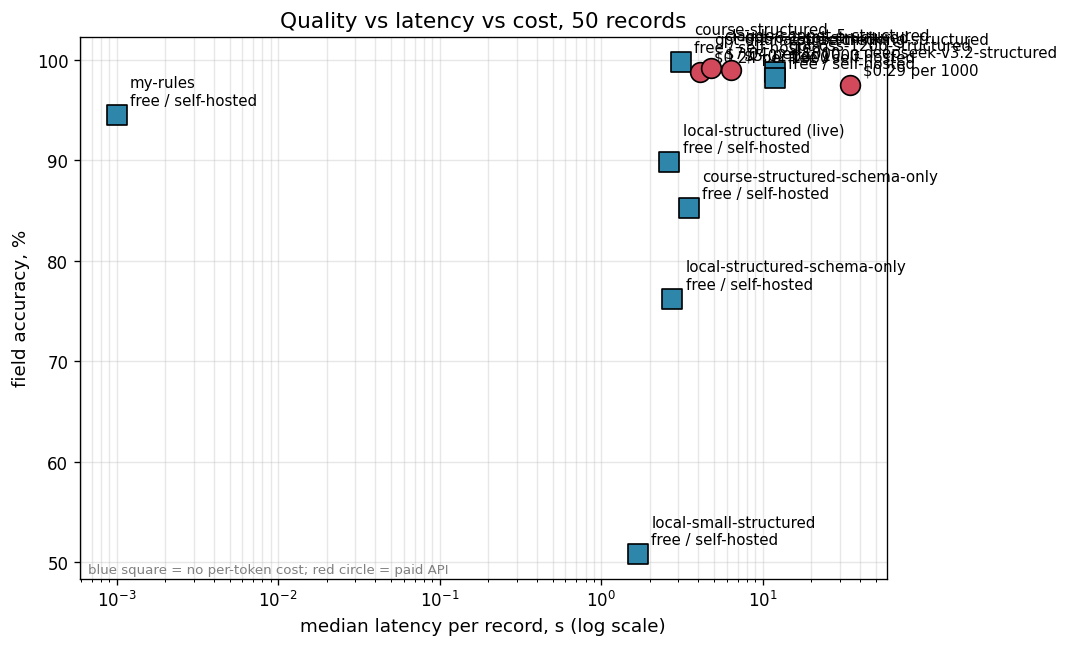

In [18]:
plot_quality_latency_cost(summaries, title=f"Quality vs latency vs cost, {len(eval_records)} records");

In [19]:
per_field_table(summaries)

,equipment_id,equipment_type,work_type,failure_mode,replaced_parts,duration_hours,work_date,downtime
my-rules,100.0,100.0,74.0,92.0,92.0,100.0,100.0,98.0
local-structured-schema-only,74.0,88.0,68.0,40.0,80.0,90.0,96.0,74.0
local-structured (live),76.0,88.0,90.0,96.0,90.0,96.0,98.0,84.0
local-small-structured,50.0,50.0,54.0,52.0,52.0,56.0,52.0,40.0
course-structured-schema-only,98.0,98.0,82.0,46.0,88.0,98.0,98.0,74.0
course-structured,100.0,100.0,98.0,100.0,100.0,100.0,100.0,100.0
course-thinking-structured,100.0,100.0,100.0,94.0,98.0,100.0,100.0,98.0
gpt-oss-120b-structured,100.0,100.0,98.0,96.0,98.0,98.0,98.0,98.0
deepseek-v3.2-structured,92.0,98.0,100.0,100.0,98.0,94.0,100.0,98.0
gpt-6-luna-structured,100.0,100.0,98.0,96.0,98.0,98.0,100.0,100.0


How to read it:
- **Validity** is close to 100% for every model with a schema and retries. Validity is not the problem anymore.
- **Field accuracy** separates the models. Look at the per-field table: which fields are hard for everybody?
- **Latency** depends on hardware: a 4B model on a laptop CPU and on a GPU differ by an order of magnitude.
  Replayed latency is the lecturer's measurement, not yours.
- **Cost**: self-hosted models have no per-token price, you pay with hardware and operations.
  Frontier APIs are not available in Russia at all.
- **Rules** are in the table too. For which fields is an LLM worth it?

## 8. Call logs

Every live call is written to `runs/<setup>/calls.jsonl`: prompt, answer, model, tokens, latency, cost.
In topic 2 these logs become test cases, in topic 6 they feed monitoring. A call log is also a replay file:
this is how the lecturer's runs got into your notebook.

In [20]:
from plant_assistant import PROJECT_ROOT, RUNS_DIR

log_files = sorted(RUNS_DIR.glob("my-*/calls.jsonl"), key=lambda p: p.stat().st_mtime)
source = log_files[-1] if log_files else replay_path("local-structured-dev20")
entry = json.loads(source.read_text(encoding="utf-8").splitlines()[0])
print("file:", source.relative_to(PROJECT_ROOT))
print(json.dumps({k: entry[k] for k in ("ts", "profile", "model", "meta", "response_format")}, indent=2))
print(json.dumps({k: entry["response"][k] for k in ("prompt_tokens", "completion_tokens", "latency_s", "cost_usd")}, indent=2))

file: runs\my-local-structured-dev20\calls.jsonl
{
  "ts": "2026-10-07T15:06:00+00:00",
  "profile": "local",
  "model": "qwen3.5:4b-q4_K_M",
  "meta": {
    "record_id": "ML-0002",
    "mode": "structured",
    "attempt": 1,
    "stage": "main"
  },
  "response_format": "MaintenanceRecord"
}
{
  "prompt_tokens": 492,
  "completion_tokens": 159,
  "latency_s": 3.818,
  "cost_usd": 0.0
}


## 9. Results and next steps

**Check yourself:** valid after retries ≥ 95% on `dev_20`; your table close to `reference/results.md`.

**What you built:** a typed contract (`MaintenanceRecord`), constrained output, business rules,
retry with the error text, fallback to human review, a rules baseline, a comparison harness and call logs.

**Homework (optional):**
1. When you get the course token: set `PRACTICE_PROFILE=course`, run the notebook live, compare thinking on and off.
2. Normalize in code, not in the model: convert Cyrillic look-alike letters and add the missing hyphen in
   `equipment_id` before the business rules. How many retries disappear? (Look at `FV305` in the logs:
   the small model could not fix it and returned `null` just to pass the check.)
3. Hybrid: run the rules first and call the LLM only for the fields the rules left empty. Compare accuracy,
   number of LLM calls and cost with "LLM for everything".
4. Two-step extraction: free-text reasoning first, then formatting. Does accuracy change?
5. Split the schema into two smaller schemas. Does accuracy change?
6. Connect a Russian API (Yandex AI Studio or GigaChat) with your own account as a new profile.
   Check that it really follows the JSON Schema.

**Next practice (topic 2):** we turn these runs into an evaluation harness with a golden set.